## CREDIT CARD FRAUD DETECTION


Machine learning project lifecycle 

1. Problem Definition
2. Data Collection
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Selection
7. Training
8. Evaluation
9. Deployment

Life cyccle of ML projectTypical machine learning project lifecycle in real industry:

# 1. Problem Definition
Financial institutions process millions of credit card transactions daily, making it difficult to manually identify fraudulent activities in real time. Fraudulent transactions cause significant financial losses, reduce customer trust, and increase operational risks for banks and payment systems.

The objective of this project is to develop a machine learning-based fraud detection system capable of accurately identifying fraudulent credit card transactions from highly imbalanced transactional data. The system should minimize false negatives (undetected fraud) while also reducing false positives that may incorrectly block legitimate customer transactions.

The model will analyze transaction patterns such as transaction amount, time, frequency, and behavioral features to classify transactions as fraudulent or legitimate. The final solution should support scalable, real-time fraud detection with high precision and recall.

# 2. Data Collection

Data Scources - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?utm_source=chatgpt.com
Data consists of 

### Importing Libraries

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the CSV file

In [80]:
df = pd.read_csv("data/creditcard.csv")

In [81]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [82]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,0.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,0.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,0.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Some information about dataset

In [83]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,14.045646,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,5.834817,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,10.000000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,15.000000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,19.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,23.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     28

# 3. Data Cleaning 
* remove duplicates
* handle null values




### Checking missing values

In [85]:
check = df.isna().sum()

print(check[check != 0])

Series([], dtype: int64)


### we have no missing values in our data set 

### Checking duplicates

In [86]:
print(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop= True)
print("Duplicated records deleted")

2804
Duplicated records deleted


### Now we zero duplicates in our dataset

### Our time feature is in seconds we will chnage it to hours so that model can check if there is any realtin of time with frauds like night or early mornings.

In [87]:
"""df["Time"] = (df["Time"] // 3600) % 24
df["Hour"].value_counts()"""

'df["Time"] = (df["Time"] // 3600) % 24\ndf["Hour"].value_counts()'

# 4. Exploratory Data Analysis (EDA)

Goal:
understand patterns before modeling.
* distributions
* correlations
* imbalance
* leakage
* anomalies
* trends



### Checking the corelation in our dataset

In [88]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,-0.004260,0.008258,-0.024096,-0.035303,-0.034233,-0.017804,-0.010378,0.033111,-0.191096,...,-0.011842,-0.015051,0.006108,0.005472,-0.003881,0.001478,-0.008273,-0.007100,-0.006763,-0.016915
V1,-0.004260,1.000000,0.007498,-0.002868,0.002387,-0.010153,-0.003036,-0.007147,-0.002393,-0.003042,...,0.003276,-0.001681,-0.002410,-0.004100,-0.003064,0.000160,-0.015559,-0.004250,-0.228581,-0.094504
V2,0.008258,0.007498,1.000000,0.005093,-0.002115,0.004385,0.001042,0.006435,0.003359,0.000854,...,-0.004471,0.001478,-0.004121,0.001261,-0.001968,-0.000087,0.007372,0.001687,-0.533483,0.084664
V3,-0.024096,-0.002868,0.005093,1.000000,0.001742,0.001439,0.005513,-0.011653,-0.000266,-0.003591,...,0.003525,-0.000381,0.000926,0.003702,0.002575,0.000551,-0.007597,-0.000756,-0.215083,-0.183509
V4,-0.035303,0.002387,-0.002115,0.001742,1.000000,0.004271,0.004045,0.003473,0.002293,0.003620,...,-0.001221,0.000214,0.000527,0.003029,0.001266,-0.001239,0.002078,0.000163,0.099125,0.129687
V5,-0.034233,-0.010153,0.004385,0.001439,0.004271,1.000000,-0.012342,-0.008527,-0.001312,-0.000541,...,0.002139,0.000353,0.001146,-0.004884,-0.002874,0.000124,-0.005986,-0.000421,-0.388573,-0.088124
V6,-0.017804,-0.003036,0.001042,0.005513,0.004045,-0.012342,1.000000,0.004834,-0.002800,-0.002817,...,-0.001683,0.002410,-0.000646,-0.007303,-0.002479,0.000406,-0.000348,0.000962,0.220121,-0.044167
V7,-0.010378,-0.007147,0.006435,-0.011653,0.003473,-0.008527,0.004834,1.000000,-0.004837,-0.001945,...,0.008721,-0.002215,0.003962,0.001767,0.000605,0.000068,-0.004274,0.001628,0.400594,-0.172710
V8,0.033111,-0.002393,0.003359,-0.000266,0.002293,-0.001312,-0.002800,-0.004837,1.000000,-0.000111,...,0.019111,-0.005818,0.004903,-0.002214,-0.000980,-0.001191,0.000309,-0.000153,-0.104368,0.033177
V9,-0.191096,-0.003042,0.000854,-0.003591,0.003620,-0.000541,-0.002817,-0.001945,-0.000111,1.000000,...,0.001080,-0.000307,0.000026,-0.002785,-0.002263,0.005305,0.007795,0.005978,-0.042382,-0.094329


<Axes: >

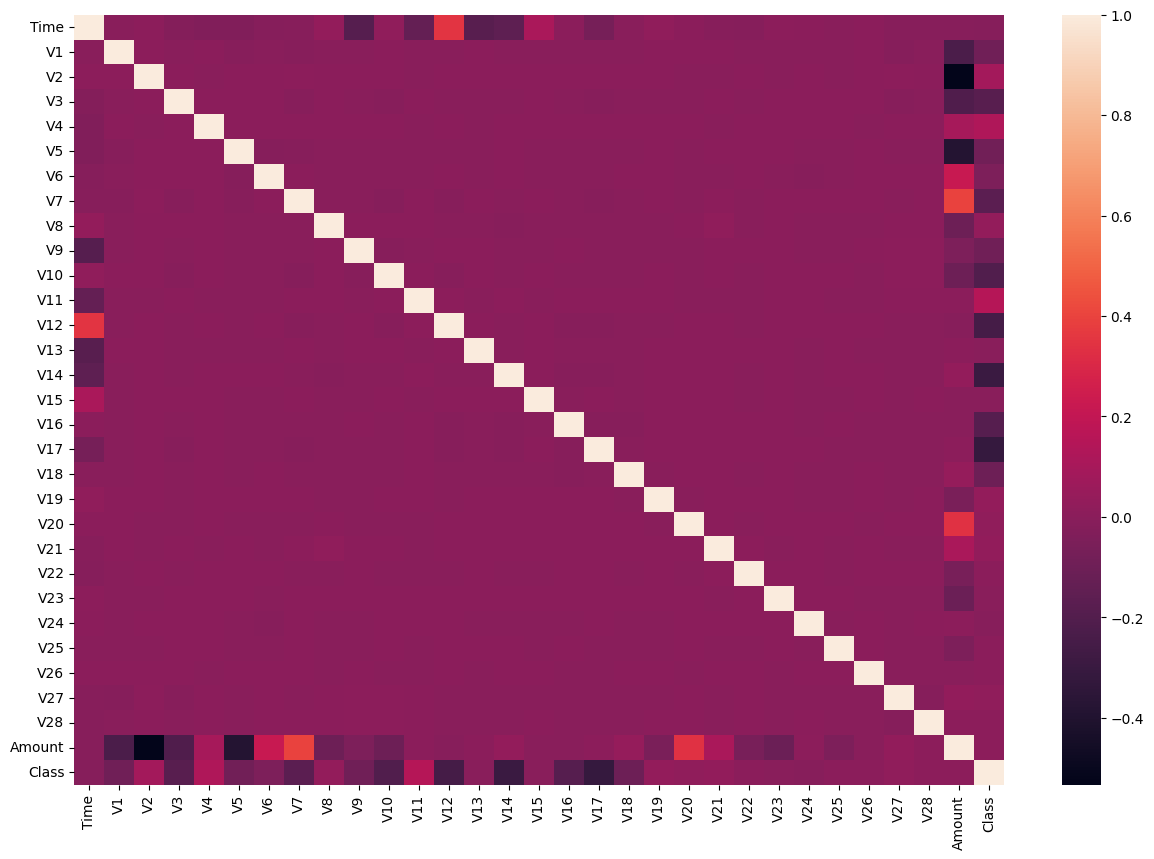

In [89]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr())

### From above heat map it is vivsible that no two features are highly correlated

### Checking for imbalance in our dataset

In [90]:
df["Class"].value_counts()

Class
0    280449
1       473
Name: count, dtype: int64

### Clearly our dataset is highly imabalanced

In [91]:
weight_0 =  (df["Class"].value_counts()[0]/(df["Class"].value_counts()[0]+df["Class"].value_counts()[1]))*100
print(f"not fraud i.e 0 is {weight_0}%  of data ")

not fraud i.e 0 is 99.83162586055916%  of data 


In [92]:
plt.figure(figsize=(15,10))
sns.countplot(x="Hour", hue="Class", data=df)

ValueError: Could not interpret value `Hour` for `x`. An entry with this name does not appear in `data`.

<Figure size 1500x1000 with 0 Axes>

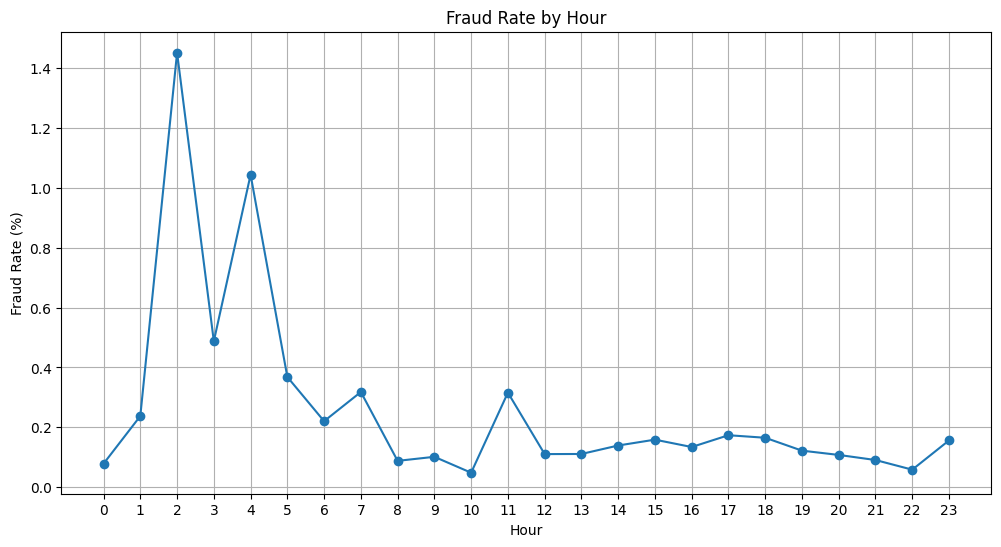

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["Hour"] = (df["Time"] // 3600) % 24
total_txns = df.groupby("Hour").size()
fraud_txns = df[df["Class"] == 1].groupby("Hour").size()
fraud_rate = (fraud_txns / total_txns) * 100
fraud_rate = fraud_rate.fillna(0)
plt.figure(figsize=(12,6))

plt.plot(
    fraud_rate.index,
    fraud_rate.values,
    marker='o'
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")

plt.xticks(range(24))
plt.grid(True)

plt.show()

* Fraud activity is significantly higher during early hours, especially around Hour 2 and Hour 4.
* Most daytime and evening hours show relatively low and stable fraud rates.
* Transaction timing appears to carry predictive signal and can help the model identify suspicious behavior patterns.
* Engineering an `Hour` feature from `Time` is justified because fraud distribution is not uniform across the day.


### How amount can help

<Axes: xlabel='Class', ylabel='Amount'>

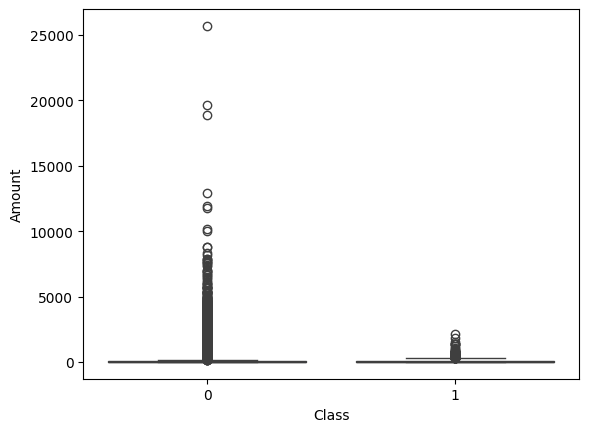

In [ ]:
sns.boxplot(x="Class", y="Amount", data=df)

# 5. Preprocessing
Here we will be transfroming our dataset based on features if they are categorical we use encoding like OnehotEncoding,LabelEncoding and if numerical we standardize them.
Since all our features are numerical we will use standard scaler on our features

In [ ]:
from sklearn.preprocessing import StandardScaler

In [94]:
df = pd.read_csv("notebooks\data\creditcard.csv")
df.head(4)

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks\\data\\creditcard.csv'

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(df.describe())

                Time            V1  ...         Amount          Class
count  284807.000000  2.848070e+05  ...  284807.000000  284807.000000
mean    94813.859575  1.168375e-15  ...      88.349619       0.001727
std     47488.145955  1.958696e+00  ...     250.120109       0.041527
min         0.000000 -5.640751e+01  ...       0.000000       0.000000
25%     54201.500000 -9.203734e-01  ...       5.600000       0.000000
50%     84692.000000  1.810880e-02  ...      22.000000       0.000000
75%    139320.500000  1.315642e+00  ...      77.165000       0.000000
max    172792.000000  2.454930e+00  ...   25691.160000       1.000000

[8 rows x 31 columns]


In [ ]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
280917    False
280918    False
280919    False
280920    False
280921    False
Length: 280922, dtype: bool

<Axes: >

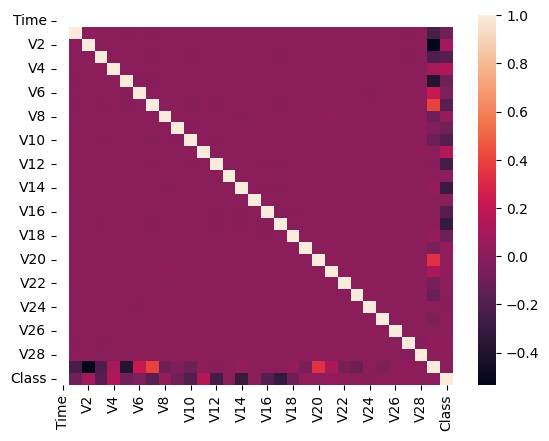

In [ ]:
sns.heatmap(df.corr())

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,0.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,0.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,0.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df["Class"].value_counts()

Class
0    280449
1       473
Name: count, dtype: int64

In [ ]:
weight_0 =  df["Class"].value_counts()[0]/(df["Class"].value_counts()[0]+df["Class"].value_counts()[1])
print(weight_0)

0.9983162586055916


In [ ]:
## it is an imbalance data set


In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
X.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69


In [ ]:
df[["Amount","Class"]].corr()

,Amount,Class
Amount,1.000000,0.005681
Class,0.005681,1.000000


In [ ]:
df[["Time","Class"]].corr()

,Time,Class
Time,NaN,NaN
Class,NaN,1.0


In [ ]:
y.head(2)

0    0
1    0
Name: Class, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size= .75,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)


LogisticRegression()

In [95]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print("confusion_matrix",confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("classification_report",classification_report(y_test,y_pred))

confusion_matrix [[70117    10]
 [   39    65]]
accuracy_score 0.9993023024020732
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70127
           1       0.87      0.62      0.73       104

    accuracy                           1.00     70231
   macro avg       0.93      0.81      0.86     70231
weighted avg       1.00      1.00      1.00     70231



In [ ]:
model1 = LogisticRegression(class_weight={0: weight_0})


In [ ]:
model1.fit(X_train,y_train)

y_pred = model1.predict(X_test)


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print("confusion_matrix",confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("classification_report",classification_report(y_test,y_pred))

confusion_matrix [[70117    10]
 [   39    65]]
accuracy_score 0.9993023024020732
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70127
           1       0.87      0.62      0.73       104

    accuracy                           1.00     70231
   macro avg       0.93      0.81      0.86     70231
weighted avg       1.00      1.00      1.00     70231



In [ ]:
from sklearn.linear_model import LogisticRegressionCV

In [ ]:
model2 = LogisticRegressionCV(class_weight={0: weight_0},cv =5)

In [ ]:
model2.fit(X_train,y_train)
y_pred = model2.predict(X_test)


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))
print("accuracy_score\n",accuracy_score(y_test,y_pred))
print("classification_report\n",classification_report(y_test,y_pred))

confusion_matrix
 [[70118     9]
 [   41    63]]
accuracy_score
 0.9992880636755849
classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70127
           1       0.88      0.61      0.72       104

    accuracy                           1.00     70231
   macro avg       0.94      0.80      0.86     70231
weighted avg       1.00      1.00      1.00     70231



In [ ]:
model3 = LogisticRegression(class_weight= "balanced")

model3.fit(X_train,y_train)

y_pred = model3.predict(X_test)


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))
print("accuracy_score\n",accuracy_score(y_test,y_pred))
print("classification_report\n",classification_report(y_test,y_pred))

confusion_matrix
 [[68299  1828]
 [    9    95]]
accuracy_score
 0.9738434594409876
classification_report
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     70127
           1       0.05      0.91      0.09       104

    accuracy                           0.97     70231
   macro avg       0.52      0.94      0.54     70231
weighted avg       1.00      0.97      0.99     70231



In [ ]:
y_prob = model2.predict_proba(X_test)
y_prob

array([[9.99439709e-01, 5.60291314e-04],
       [9.99866782e-01, 1.33218382e-04],
       [9.99380862e-01, 6.19137688e-04],
       ...,
       [9.99839745e-01, 1.60254588e-04],
       [9.99934104e-01, 6.58959122e-05],
       [9.98213569e-01, 1.78643137e-03]])

In [ ]:
y_prob = model2.predict_proba(X_test)[:,1]
y_prob

array([5.60291314e-04, 1.33218382e-04, 6.19137688e-04, ...,
       1.60254588e-04, 6.58959122e-05, 1.78643137e-03])

In [ ]:
val = .3332
y_pred = (y_prob > val).astype(int)
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))
print("accuracy_score\n",accuracy_score(y_test,y_pred))
print("classification_report\n",classification_report(y_test,y_pred))

confusion_matrix
 [[70117    10]
 [   35    69]]
accuracy_score
 0.9993592573080263
classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70127
           1       0.87      0.66      0.75       104

    accuracy                           1.00     70231
   macro avg       0.94      0.83      0.88     70231
weighted avg       1.00      1.00      1.00     70231



In [96]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate= 0.05)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

print("confusion_matrix\n",confusion_matrix(y_test,y_pred))
print("accuracy_score\n",accuracy_score(y_test,y_pred))
print("classification_report\n",classification_report(y_test,y_pred))

confusion_matrix
 [[70122     5]
 [   19    85]]
accuracy_score
 0.9996582705642807
classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70127
           1       0.94      0.82      0.88       104

    accuracy                           1.00     70231
   macro avg       0.97      0.91      0.94     70231
weighted avg       1.00      1.00      1.00     70231



In [2]:
import pandas as pd

df = pd.read_csv("data\creditcard.csv")

fraud = df[df["Class"] == 1].head(1)
legit = df[df["Class"] == 0].head(1)

print("LEGIT")
print(legit.to_dict(orient="records")[0])

print("\nFRAUD")
print(fraud.to_dict(orient="records")[0])

LEGIT
{'Time': 0.0, 'V1': -1.3598071336738, 'V2': -0.0727811733098497, 'V3': 2.53634673796914, 'V4': 1.37815522427443, 'V5': -0.338320769942518, 'V6': 0.462387777762292, 'V7': 0.239598554061257, 'V8': 0.0986979012610507, 'V9': 0.363786969611213, 'V10': 0.0907941719789316, 'V11': -0.551599533260813, 'V12': -0.617800855762348, 'V13': -0.991389847235408, 'V14': -0.311169353699879, 'V15': 1.46817697209427, 'V16': -0.470400525259478, 'V17': 0.207971241929242, 'V18': 0.0257905801985591, 'V19': 0.403992960255733, 'V20': 0.251412098239705, 'V21': -0.018306777944153, 'V22': 0.277837575558899, 'V23': -0.110473910188767, 'V24': 0.0669280749146731, 'V25': 0.128539358273528, 'V26': -0.189114843888824, 'V27': 0.133558376740387, 'V28': -0.0210530534538215, 'Amount': 149.62, 'Class': 0}

FRAUD
{'Time': 0.0, 'V1': -2.3122265423263, 'V2': 1.95199201064158, 'V3': -1.60985073229769, 'V4': 3.9979055875468, 'V5': -0.522187864667764, 'V6': -1.42654531920595, 'V7': -2.53738730624579, 'V8': 1.39165724829804, '

In [ ]:
pipeline = PredPipeline()
result = pipeline.predict(pred_df)

print(type(result))
print(result)